# **Linear Discriminant Analysis (LDA)**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## **Step 1:Loading dataset and Splitting it.**

In [ ]:
iris = '/content/iris.data'

Creating a DataFrame for better visualization => makes the dataset easier to read with proper column names and labeled target values.

In [ ]:
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_data = pd.read_csv(iris, header=None, names=columns)#read the file and load it into a DataFrame

In [ ]:
#check the structure of the dataset
print(iris_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [ ]:
#displayed the first rows
print(iris_data.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [ ]:
#check unique target values (species) from the DataFrame
print("\nUnique target values (species):", iris_data['species'].unique())


Unique target values (species): ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
#splitting
X = iris_data.iloc[:, :-1].values #features (sepal length, sepal width, petal length, petal width)
y = iris_data['species'].values #target(species)

#split the data into training(70%) and testing(30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#printing the shape of the training and testing sets
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")


Training data shape: (105, 4), Training labels shape: (105,)
Testing data shape: (45, 4), Testing labels shape: (45,)


## **Step 2:Apply LDA and Train a Classifier**

using Linear Discriminant Analysis (LDA) as a technique to reduce the number of features (dimensions) in the dataset while retaining as much of the relevant information as possible for classification tasks. Iris dataset has 4 features: sepal_length, sepal_width, petal_length, and petal_width.
Applying LDA reduces these 4 features to fewer dimensions (in this case, 2), which simplifies the dataset. Useful to make the learning task more manageable.
Reduced the dataset to 2 components while maximizing class separability.

In [ ]:
from sklearn.preprocessing import LabelEncoder
#encode the target(species) into numerical values using LabelEncoder
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  #encode y_train
y_test_encoded = encoder.transform(y_test)  #encode y_test

#apply LDA to reduce dimensionality
lda = LinearDiscriminantAnalysis(n_components=2)  #reduce to 2 components
X_train_lda = lda.fit_transform(X_train, y_train_encoded)
X_test_lda = lda.transform(X_test)

Train a Logistic Regression classifier on the transformed data.

**Logistic Regression (LR)**

It's a probabilistic model that predicts the probability of a sample belonging to a specific class.
It uses a linear decision boundary (a straight line or plane) to separate classes.
The model optimizes a cost function based on the log-likelihood of the data.

In [ ]:
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_lda, y_train_encoded)

LogisticRegression(random_state=42)

In [ ]:
#predict on the test set
y_pred = classifier.predict(X_test_lda)

## **Step 3:Evaluate the classifier(Performance Evaluation).**

In [ ]:
print(set(type(x) for x in y_test))
print(set(type(x) for x in y_pred))


{<class 'str'>}
{<class 'numpy.int64'>}


In [ ]:
#calculate the Accuracy, Precision, Recall and F1 Score based on the confusion matrix.
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
#confusion matrix rows=>the true classes(actual labels), columns=>the predicted classes.
#[19 0 0] means that 19 samples of class 0(setosa) were correctly predicted while none were misclassified as classes 1 or 2.
#19(true positive) samples of setosa were correctly classified as setosa.
#13(true positive) samples of versicolor were correctly classified as versicolor.
#13(true positive) samples of virginica were correctly classified as virginica.

ValueError: Mix of label input types (string and number)

In [ ]:
#the confusion matrix is in the form: [[TP, FP], [FN, TN]]
#for multi-class classification, we get a matrix with more values,
#but handling it for the relevant class (binary or multi-class).
TP = conf_matrix[0, 0]  #True Positive
FP = conf_matrix[0, 1]  #False Positive
FN = conf_matrix[1, 0]  #False Negative
TN = conf_matrix[1, 1]  #True Negative

In [ ]:
#using Accuracy
accuracy = (TP + TN) / (TP + FP + FN + TN)
print(f"Accuracy: {accuracy * 100:.2f}%")#accuracy * 100:converts accuracy from a decimal to a percentage.
                                          #:.2f:format specifier to format the number as a floating-point number with two decimal places
#100% means that the classifier correctly classified all samples in the test set.

Accuracy: nan%


<ipython-input-35-a10d22f758ad>:2: RuntimeWarning: invalid value encountered in scalar divide
  accuracy = (TP + TN) / (TP + FP + FN + TN)


In [ ]:
#using Precision
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
print(f"Precision: {precision:.2f}")

Precision: 1.00


In [ ]:
#using Recall
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
print(f"Recall: {recall:.2f}")

Recall: 1.00


In [ ]:
#using F1 Score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
print(f"F1 Score: {f1_score:.2f}")

F1 Score: 1.00


Accuracy: 100%: All samples were classified correctly.

---


Precision: 1.00: All positive predictions were correct.

---


Recall: 1.00: All actual positive samples were correctly identified.

---


F1 Score: 1.00: The classifier balanced Precision and Recall perfectly.

## **Step 4:Visualization**

### Step 1: Visualizing the LDA-Transformed Data

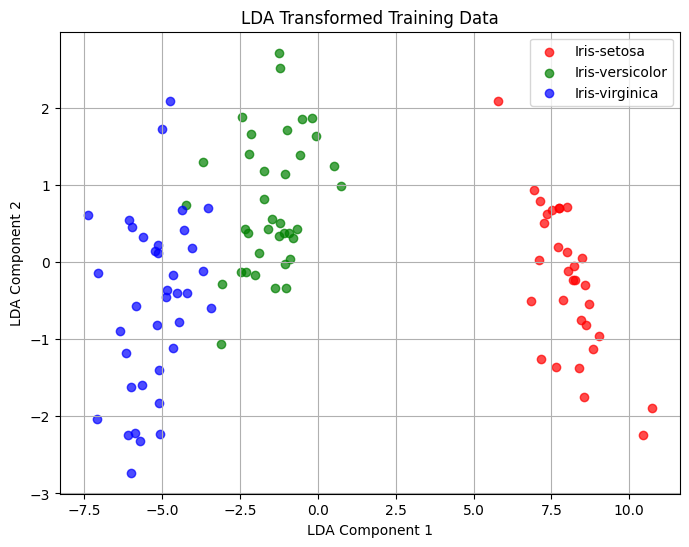

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

#define colors for each class
colors = ['red', 'green', 'blue']
labels = encoder.classes_  #use original species names from the encoder

#scatter plot for each class
for i, label in enumerate(labels):
    plt.scatter(
        X_train_lda[y_train_encoded == i, 0],  # LDA component 1
        X_train_lda[y_train_encoded == i, 1],  # LDA component 2
        label=label,
        color=colors[i],
        alpha=0.7
    )

#add title, labels, legend, and grid
plt.title('LDA Transformed Training Data')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Step 2: Plotting the Decision Boundaries

Plotted decision boundaries to show how the classifier separates the classes.

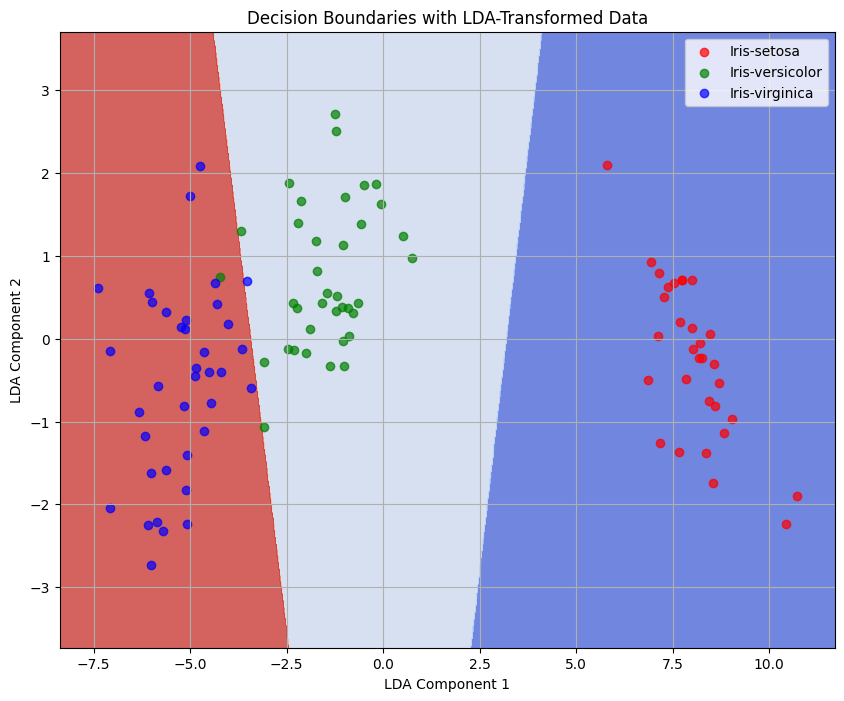

In [ ]:
#plotting the decision boundary using the already computed X_lda
h = 0.02  #step size in the mesh

#the min and max values for each axis of the LDA-transformed data
x_min, x_max = X_train_lda[:, 0].min() - 1, X_train_lda[:, 0].max() + 1
y_min, y_max = X_train_lda[:, 1].min() - 1, X_train_lda[:, 1].max() + 1

#creating a mesh grid
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
#predict the class labels for the mesh points
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotting the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

#scatter plot the LDA-transformed training data
colors = ['red', 'green', 'blue']
labels = encoder.classes_  # Get original species names from the encoder

for i, label in enumerate(labels):
    plt.scatter(X_train_lda[y_train_encoded == i, 0],
                X_train_lda[y_train_encoded == i, 1],
                label=label, color=colors[i], alpha=0.7)

#add title, labels, legend, and grid
plt.title('Decision Boundaries with LDA-Transformed Data')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend(loc='best')
plt.grid(True)
plt.show()



# Adding other classifiers to compare

**K-Nearest Neighbors (KNN)**

It's a non-parametric, instance-based algorithm that classifies a sample based on the majority class of its k nearest neighbors in the feature space.
It does not build a model instead, it directly uses the training data during prediction.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#Step 1: initialize and train the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3)  #made 'n_neighbors'=3 meaning it considers the 3 nearest neighbors to classify a sample.
knn_classifier.fit(X_train_lda, y_train_encoded)

#Step 2: predict on the test set
y_pred_knn = knn_classifier.predict(X_test_lda)


In [ ]:
#Step 3:evaluate the KNN classifier
accuracy_knn = accuracy_score(y_test_encoded, y_pred_knn)  #compare the encoded test labels with predicted labels
conf_matrix_knn = confusion_matrix(y_test_encoded, y_pred_knn)

#display the results
print("\nKNN Classifier Results:")
print(f"Accuracy: {accuracy_knn * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix_knn)


KNN Classifier Results:
Accuracy: 100.00%
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


**Plotting KNN Decision Boundaries**

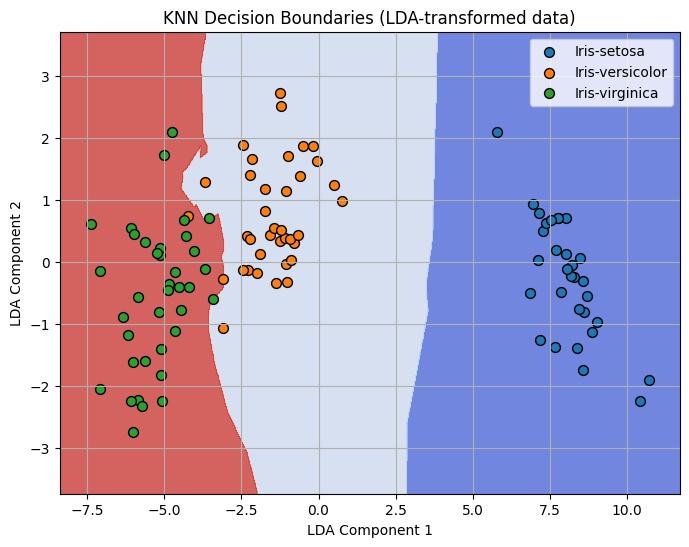

In [ ]:
#predict class labels for each point in the mesh using the KNN classifier
Z_knn = knn_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z_knn = Z_knn.reshape(xx.shape)

#plot the decision boundaries and scatter points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_knn, alpha=0.8, cmap=plt.cm.coolwarm)

#plot the original training points
for i, label in enumerate(encoder.classes_):  #use encoder.classes_ for species names
    plt.scatter(X_train_lda[y_train_encoded == i, 0], X_train_lda[y_train_encoded == i, 1],
                label=label, edgecolor='k', s=50)

plt.title('KNN Decision Boundaries (LDA-transformed data)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
#display the legend
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#with n_neighbors=2 meaning it considers the 2 nearest neighbors to classify a sample.
knn_classifier = KNeighborsClassifier(n_neighbors=2)
knn_classifier.fit(X_train_lda, y_train_encoded)

#predict on the test set
y_pred_knn = knn_classifier.predict(X_test_lda)

#evaluation of the KNN classifier
accuracy_knn = accuracy_score(y_test_encoded, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_encoded, y_pred_knn)

#results
print("\nKNN Classifier Results:")
print(f"Accuracy: {accuracy_knn * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix_knn)



KNN Classifier Results:
Accuracy: 97.78%
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]


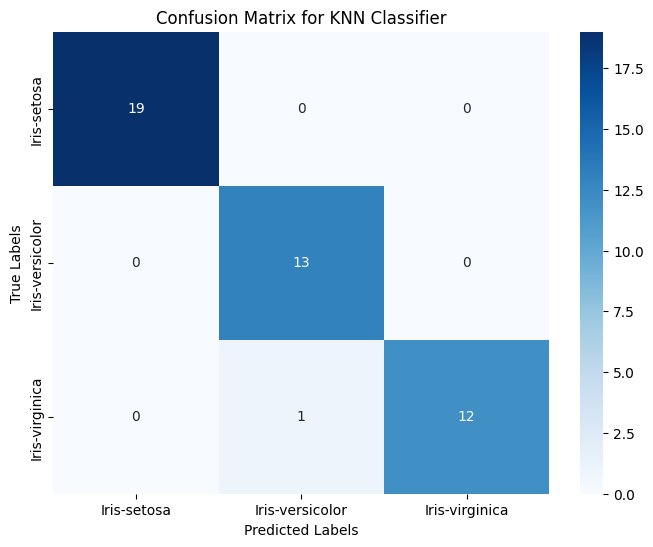

In [ ]:
import seaborn as sns
#plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix for KNN Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

**Support Vector Machine (SVM)**

SVM aims to find the optimal decision boundary that separates classes with the maximum margin (the widest gap between the classes and the boundary).
Uses kernel tricks to handle non-linear data by mapping it into higher-dimensional spaces where it becomes linearly separable.

SVM Classifier Results:
Accuracy: 100.00%
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


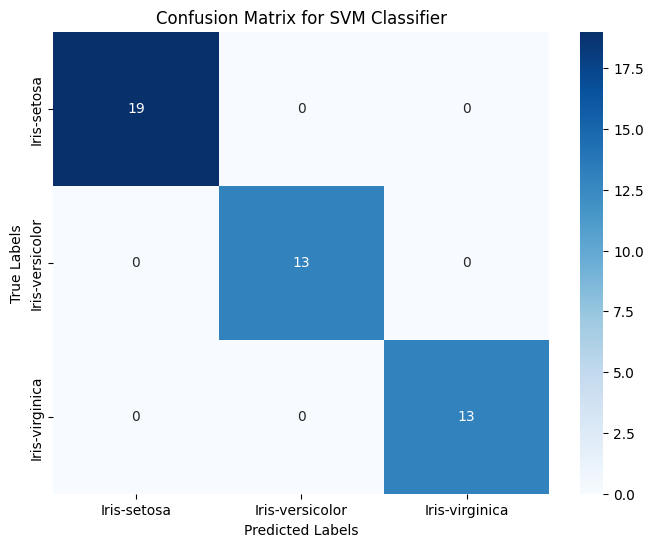

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

#Step 1:initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)#the SVC classifier is used with a linear kernel
svm_classifier.fit(X_train_lda, y_train_encoded)

#Step 2:predict on the test set
y_pred_svm = svm_classifier.predict(X_test_lda)

#Step 3:evaluate the SVM classifier
accuracy_svm = accuracy_score(y_test_encoded, y_pred_svm)  #ccompare with encoded test labels
conf_matrix_svm = confusion_matrix(y_test_encoded, y_pred_svm)

#displaying the results
print("SVM Classifier Results:")
print(f"Accuracy: {accuracy_svm * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix_svm)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix for SVM Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



**Plotting the decision boundaries**

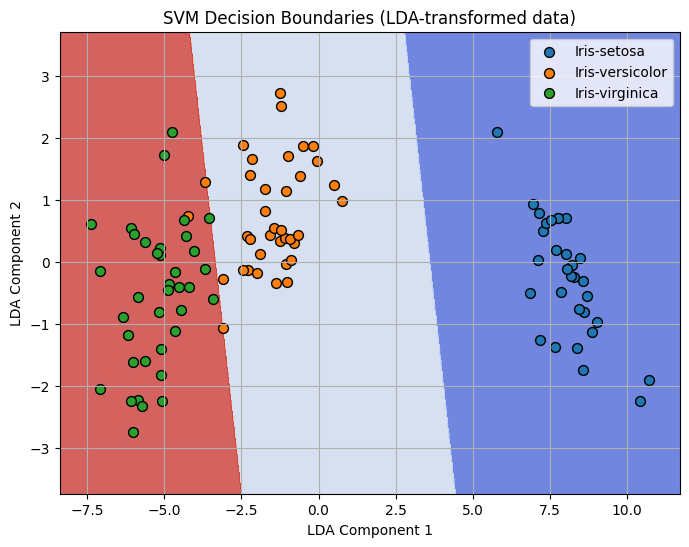

In [ ]:
#create a mesh grid for the 2D LDA space
h = 0.02  #step size in the mesh
x_min, x_max = X_train_lda[:, 0].min() - 1, X_train_lda[:, 0].max() + 1
y_min, y_max = X_train_lda[:, 1].min() - 1, X_train_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

#predict class labels for each point in the mesh using the SVM classifier
Z_svm = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

#plotting the decision boundaries and scatter points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_svm, alpha=0.8, cmap=plt.cm.coolwarm)

#plotting the original training points
for i, label in enumerate(encoder.classes_):  # Corrected to use encoder.classes_
    plt.scatter(X_train_lda[y_train_encoded == i, 0], X_train_lda[y_train_encoded == i, 1],
                label=label, edgecolor='k', s=50)

plt.title('SVM Decision Boundaries (LDA-transformed data)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend(loc='best')
plt.grid(True)
plt.show()